In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split,StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier,ExtraTreesClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import classification_report,roc_auc_score,precision_recall_curve,auc,confusion_matrix,ConfusionMatrixDisplay,f1_score

In [2]:
df=pd.read_csv("../data/raw/Bank Customer Churn Prediction.csv")
df.drop(columns="customer_id", inplace=True)
df.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df["high_products"] = (df["products_number"] >= 3).astype(int)        #  near-deterministic churn
df["country_active"] = df["country"] + "_" + df["active_member"].astype(str)

In [4]:
df.drop(columns=["credit_card"], inplace=True)

In [5]:
df = pd.get_dummies(df, columns=["country", "gender", "country_active"], drop_first=True)
df.head(3).T

,0,1,2
credit_score,619,608,502
age,42,41,42
tenure,2,1,8
balance,0.0,83807.86,159660.8
products_number,1,1,3
active_member,1,1,0
estimated_salary,101348.88,112542.58,113931.57
churn,1,0,1
high_products,0,0,1
country_Germany,False,False,False


In [6]:
X = df.drop(columns="churn")
y = df["churn"]

In [7]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [8]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

In [9]:
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
    ),
    "LightGBM": LGBMClassifier(
        class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "CatBoost": CatBoostClassifier(
        auto_class_weights="Balanced", verbose=0, random_state=42
    ),
    "Naive Bayes": GaussianNB(),   
}

In [10]:
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained.")

C:\Users\shubh\scoop\apps\python\current\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression trained.
Decision Tree trained.
Random Forest trained.
Extra Trees trained.
Gradient Boosting trained.
AdaBoost trained.
XGBoost trained.
[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000737 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 867
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
LightGBM trained.
CatBoost trained.
Naive Bayes trained.



=== Logistic Regression ===
              precision    recall  f1-score   support

           0      0.925     0.756     0.832      1593
           1      0.443     0.759     0.559       407

    accuracy                          0.756      2000
   macro avg      0.684     0.758     0.696      2000
weighted avg      0.827     0.756     0.776      2000

ROC-AUC: 0.836 | PR-AUC: 0.599


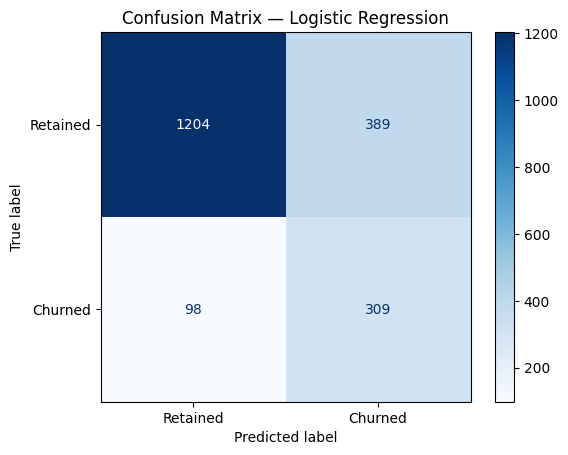


=== Decision Tree ===
              precision    recall  f1-score   support

           0      0.860     0.859     0.860      1593
           1      0.451     0.455     0.453       407

    accuracy                          0.776      2000
   macro avg      0.656     0.657     0.656      2000
weighted avg      0.777     0.776     0.777      2000

ROC-AUC: 0.657 | PR-AUC: 0.508


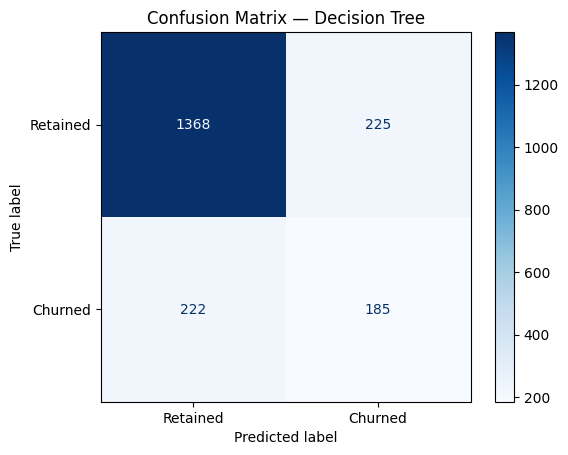


=== Random Forest ===
              precision    recall  f1-score   support

           0      0.874     0.965     0.918      1593
           1      0.772     0.457     0.574       407

    accuracy                          0.862      2000
   macro avg      0.823     0.711     0.746      2000
weighted avg      0.853     0.862     0.848      2000

ROC-AUC: 0.853 | PR-AUC: 0.687


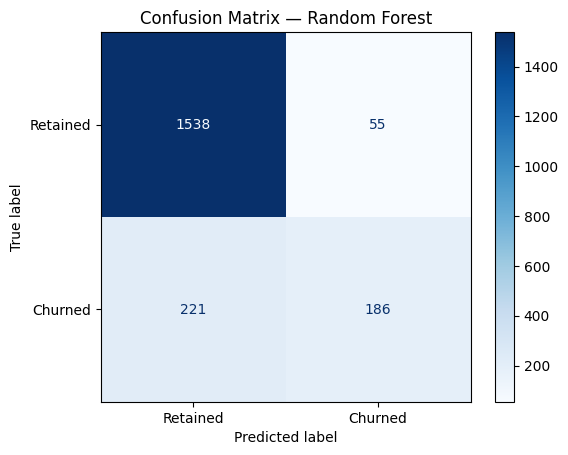


=== Extra Trees ===
              precision    recall  f1-score   support

           0      0.871     0.963     0.915      1593
           1      0.753     0.442     0.557       407

    accuracy                          0.857      2000
   macro avg      0.812     0.703     0.736      2000
weighted avg      0.847     0.857     0.842      2000

ROC-AUC: 0.846 | PR-AUC: 0.671


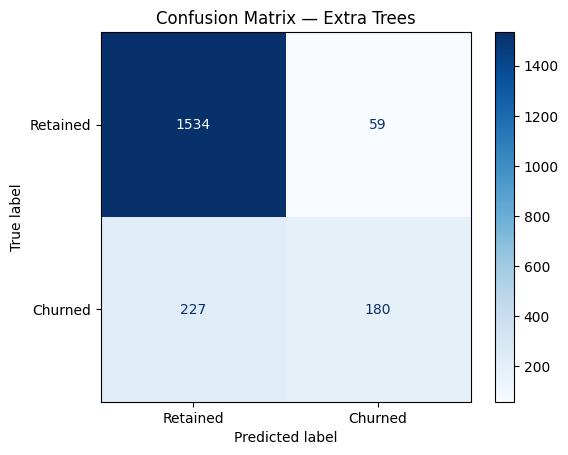


=== Gradient Boosting ===
              precision    recall  f1-score   support

           0      0.882     0.968     0.923      1593
           1      0.797     0.491     0.608       407

    accuracy                          0.871      2000
   macro avg      0.839     0.730     0.765      2000
weighted avg      0.864     0.871     0.859      2000

ROC-AUC: 0.869 | PR-AUC: 0.718


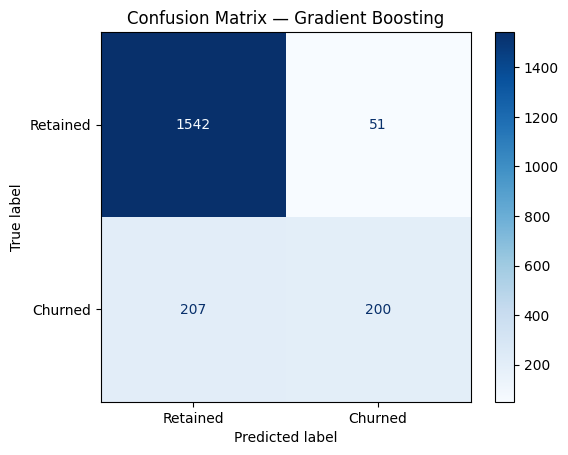


=== AdaBoost ===
              precision    recall  f1-score   support

           0      0.873     0.964     0.916      1593
           1      0.763     0.452     0.568       407

    accuracy                          0.860      2000
   macro avg      0.818     0.708     0.742      2000
weighted avg      0.851     0.860     0.846      2000

ROC-AUC: 0.848 | PR-AUC: 0.669


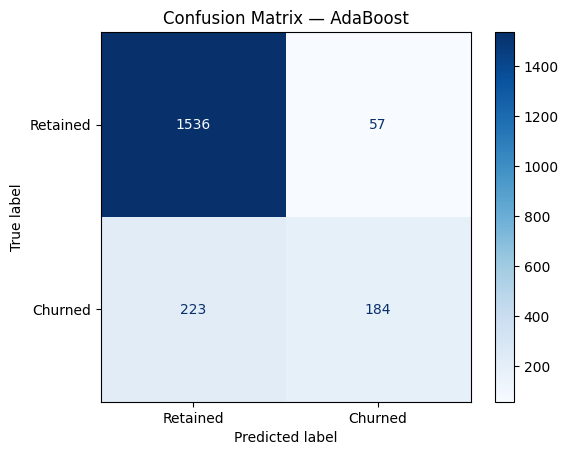


=== XGBoost ===
              precision    recall  f1-score   support

           0      0.906     0.867     0.886      1593
           1      0.554     0.646     0.596       407

    accuracy                          0.822      2000
   macro avg      0.730     0.757     0.741      2000
weighted avg      0.834     0.822     0.827      2000

ROC-AUC: 0.831 | PR-AUC: 0.664


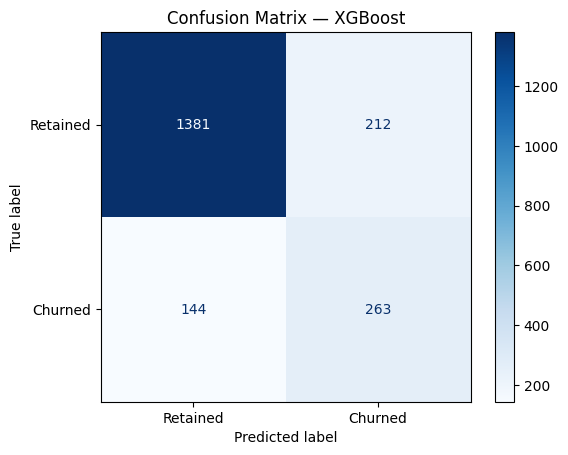


=== LightGBM ===
              precision    recall  f1-score   support

           0      0.921     0.837     0.877      1593
           1      0.530     0.720     0.610       407

    accuracy                          0.813      2000
   macro avg      0.726     0.778     0.744      2000
weighted avg      0.842     0.813     0.823      2000

ROC-AUC: 0.862 | PR-AUC: 0.706


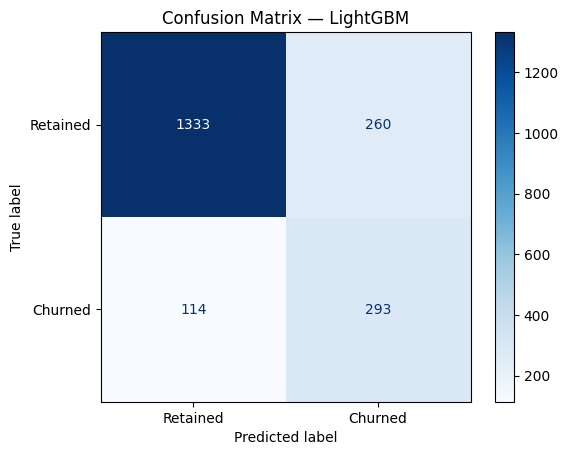


=== CatBoost ===
              precision    recall  f1-score   support

           0      0.919     0.844     0.880      1593
           1      0.536     0.708     0.610       407

    accuracy                          0.816      2000
   macro avg      0.727     0.776     0.745      2000
weighted avg      0.841     0.816     0.825      2000

ROC-AUC: 0.860 | PR-AUC: 0.714


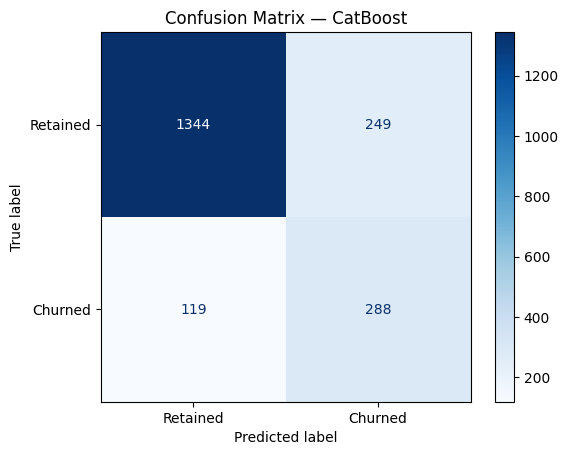


=== Naive Bayes ===
              precision    recall  f1-score   support

           0      0.802     0.972     0.879      1593
           1      0.362     0.061     0.105       407

    accuracy                          0.787      2000
   macro avg      0.582     0.517     0.492      2000
weighted avg      0.713     0.787     0.722      2000

ROC-AUC: 0.751 | PR-AUC: 0.396


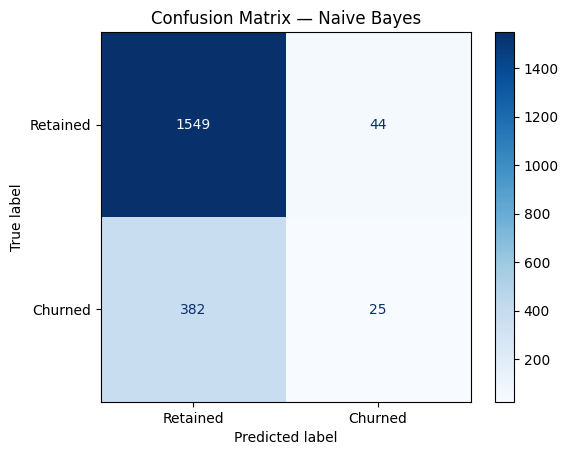


Model comparison:
                      roc_auc    pr_auc
Gradient Boosting    0.868729  0.718332
LightGBM             0.861632  0.705618
CatBoost             0.860022  0.713780
Random Forest        0.852962  0.686903
AdaBoost             0.848112  0.668903
Extra Trees          0.846199  0.671371
Logistic Regression  0.835669  0.599006
XGBoost              0.831058  0.664124
Naive Bayes          0.750539  0.396104
Decision Tree        0.656651  0.508382


In [ ]:
results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, digits=3))

    roc_auc = roc_auc_score(y_test, y_proba)
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)

    print(f"ROC-AUC: {roc_auc:.3f} | PR-AUC: {pr_auc:.3f}")
    results[name] = {"roc_auc": roc_auc, "pr_auc": pr_auc}

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Retained", "Churned"]).plot(cmap="Blues")
    plt.title(f"Confusion Matrix — {name}")
    plt.show()


In [12]:

results_df = pd.DataFrame(results).T
print("\nModel comparison:")
print(results_df.sort_values("roc_auc", ascending=False))


Model comparison:
                      roc_auc    pr_auc
Gradient Boosting    0.868729  0.718332
LightGBM             0.861632  0.705618
CatBoost             0.860022  0.713780
Random Forest        0.852962  0.686903
AdaBoost             0.848112  0.668903
Extra Trees          0.846199  0.671371
Logistic Regression  0.835669  0.599006
XGBoost              0.831058  0.664124
Naive Bayes          0.750539  0.396104
Decision Tree        0.656651  0.508382


In [13]:
best_model = models["Gradient Boosting"]  

importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

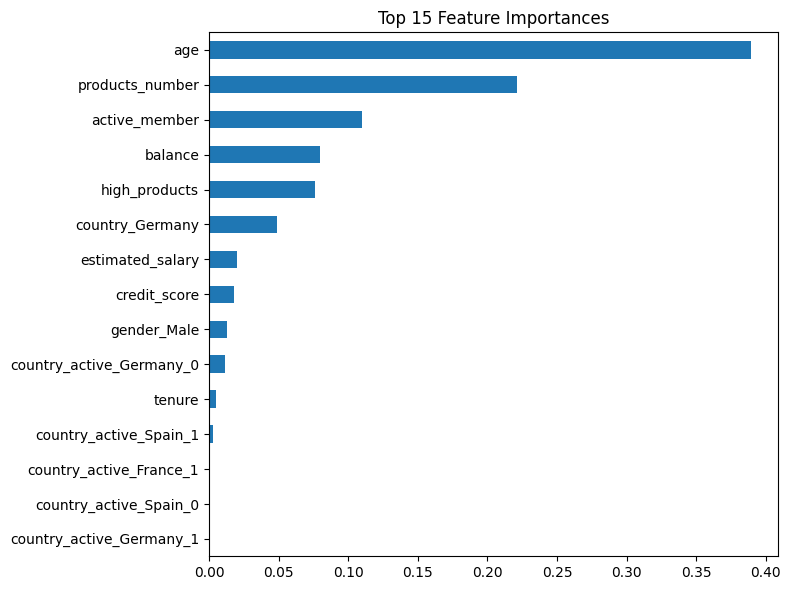

In [14]:
plt.figure(figsize=(8, 6))
importances.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()

In [15]:
y_proba = best_model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

In [16]:
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

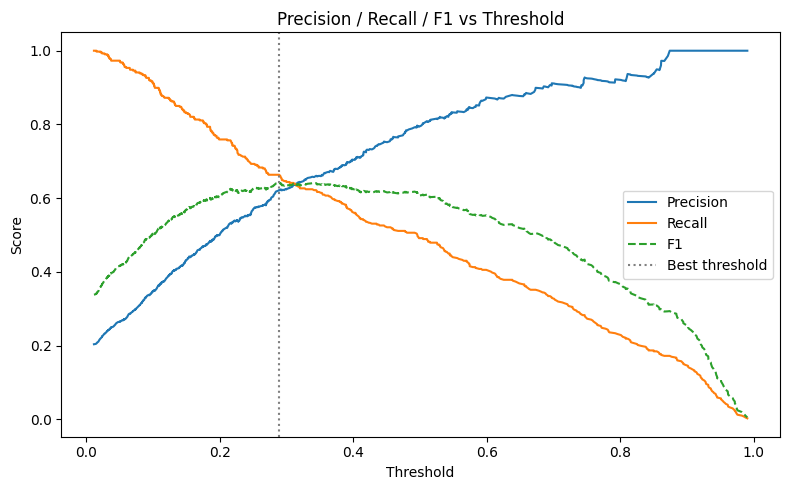

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.plot(thresholds, f1_scores[:-1], label="F1", linestyle="--")
plt.axvline(best_threshold, color="gray", linestyle=":", label="Best threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs Threshold")
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
y_pred_tuned = (y_proba >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_tuned, digits=3))

              precision    recall  f1-score   support

           0      0.913     0.897     0.905      1593
           1      0.622     0.663     0.642       407

    accuracy                          0.850      2000
   macro avg      0.767     0.780     0.773      2000
weighted avg      0.853     0.850     0.851      2000



In [19]:
import joblib

In [22]:
best_model_name = results_df["roc_auc"].idxmax()
best_model = models[best_model_name]
print(f"Best model: {best_model_name} (ROC-AUC: {results_df.loc[best_model_name, 'roc_auc']:.3f})")


Best model: Gradient Boosting (ROC-AUC: 0.869)


In [23]:
joblib.dump(best_model, "model.pkl")

['model.pkl']

In [24]:
loaded_model = joblib.load("model.pkl")

sample_pred = loaded_model.predict(X_test.iloc[:5])
sample_proba = loaded_model.predict_proba(X_test.iloc[:5])[:, 1]

print("Predictions:", sample_pred)
print("Probabilities:", sample_proba.round(3))

Predictions: [0 0 0 0 0]
Probabilities: [0.022 0.09  0.03  0.045 0.096]


In [25]:
import json

joblib.dump(list(X_train.columns), "model_columns.pkl")

with open("model_metadata.json", "w") as f:
    json.dump(
        {
            "model_name": best_model_name,
            "threshold": float(best_threshold),
            "roc_auc": float(results_df.loc[best_model_name, "roc_auc"]),
            "pr_auc": float(results_df.loc[best_model_name, "pr_auc"]),
        },
        f,
        indent=2,
    )
